## What is the most optimal skill to learn for Data Analysts?

### Methodology

1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

In [1]:
# Import Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_MX = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Mexico')].copy()

In [3]:
df_DA_MX = df_DA_MX.dropna(subset=['salary_year_avg'])

df_DA_MX_exploded = df_DA_MX.explode('job_skills')

df_DA_MX_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
5478,70500.0,sql
116903,99150.0,python
116903,99150.0,plotly
116903,99150.0,pandas
116903,99150.0,seaborn


In [4]:
df_DA_skills = df_DA_MX_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_MX)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
excel,16,98825.0,43.243243
tableau,13,80850.0,35.135135
power bi,12,89675.0,32.432432
sql,11,111175.0,29.729730
python,8,111175.0,21.621622
sheets,7,57500.0,18.918919
looker,5,111175.0,13.513514
r,4,111175.0,10.810811
express,3,53014.0,8.108108


<function matplotlib.pyplot.show(close=None, block=None)>

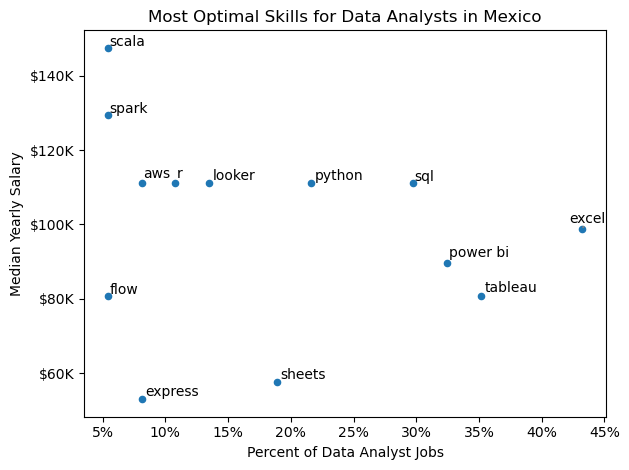

In [5]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title and legen
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in Mexico')

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot
plt.tight_layout()
plt.show

In [6]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict: # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                      # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['word',
  'looker',
  'cognos',
  'sheets',
  'alteryx',
  'datarobot',
  'powerpoint',
  'ssis',
  'msaccess',
  'nuix',
  'ms access',
  'power bi',
  'sharepoint',
  'qlik',
  'esquisse',
  'splunk',
  'tableau',
  'ssrs',
  'powerbi',
  'spreadsheet',
  'sap',
  'spss',
  'excel',
  'visio',
  'microstrategy',
  'sas',
  'outlook',
  'dax'],
 'programming': ['visual basic',
  'golang',
  'swift',
  'java',
  'shell',
  'html',
  'julia',
  'kotlin',
  'visualbasic',
  'assembly',
  'bash',
  'c#',
  'delphi',
  'matlab',
  'mongodb',
  'clojure',
  'elixir',
  'solidity',
  'javascript',
  'vba',
  'typescript',
  'vb.net',
  'python',
  'php',
  'erlang',
  'go',
  'cobol',
  'powershell',
  'nosql',
  'crystal',
  'lisp',
  'lua',
  'c',
  't-sql',
  'mongo',
  'objective-c',
  'haskell',
  'ruby',
  'scala',
  'fortran',
  'dart',
  'no-sql',
  'r',
  'perl',
  'rust',
  'css',
  'groovy',
  'f#',
  'ocaml',
  'sql',
  'sas',
  'c++',
  'apl',
  'sass',
  'pas

In [9]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,word
0,analyst_tools,looker
0,analyst_tools,cognos
0,analyst_tools,sheets
0,analyst_tools,alteryx
...,...,...
9,sync,microsoft teams
9,sync,google chat
9,sync,slack
9,sync,mattermost


In [12]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

df_plot

,skill_count,median_salary,skill_percent,technology,skills
0,16,98825.0,43.243243,analyst_tools,excel
1,13,80850.0,35.135135,analyst_tools,tableau
2,12,89675.0,32.432432,analyst_tools,power bi
3,11,111175.0,29.729730,programming,sql
4,8,111175.0,21.621622,programming,python
5,7,57500.0,18.918919,analyst_tools,sheets
6,5,111175.0,13.513514,analyst_tools,looker
7,4,111175.0,10.810811,programming,r
8,3,53014.0,8.108108,webframeworks,express
9,3,111175.0,8.108108,cloud,aws


<function matplotlib.pyplot.show(close=None, block=None)>

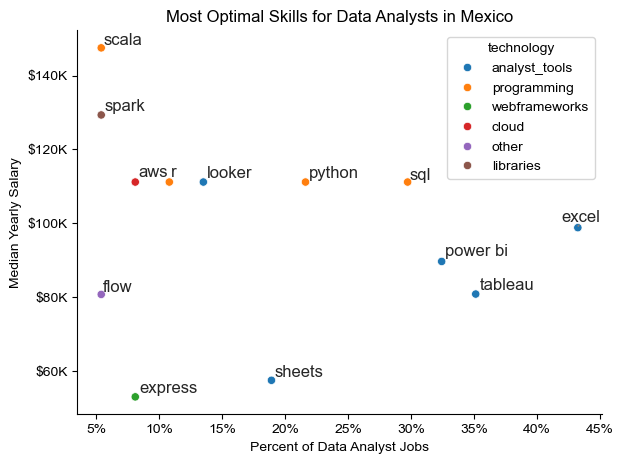

In [15]:
from adjustText import adjust_text

# df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')

sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title and legen
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in Mexico')

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot
plt.tight_layout()
plt.show